# Model Inversion Attack
## Bethany Amanuel, bes5ve

## 1. Imports and Reproducibility

First, the model weights are frozen during the attack.
Second, the input image is created with `requires_grad=True` so that gradients flow back to the pixels rather than to the network parameters.

In [1]:
import os
import math
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from skimage.metrics import structural_similarity as ssim

'''Reproducibility'''
SEED = 5581
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2. Load the Dataset

This cell follows the walkthrough setup from the lab instructions. Pixel values are scaled into the range `[0, 1]`.

In [2]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root=".",
    train=True,
    download=True,
    transform=transform,
)

test_data = datasets.MNIST(
    root=".",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

class_names = [str(i) for i in range(10)]

print(f"Training examples: {len(train_data)}")
print(f"Test examples: {len(test_data)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.41MB/s]

Training examples: 60000
Test examples: 10000


## 3. Target Model

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.fc(self.conv(x))


model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)

SimpleCNN(
  (conv): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 4. Training the Target Model

In [4]:
def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


num_epochs = 5
history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        running_correct += (logits.argmax(dim=1) == labels).sum().item()
        running_total += labels.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    test_loss, test_acc = evaluate_model(model, test_loader, criterion)

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4%} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4%}"
    )

torch.save(model.state_dict(), "target_model.pth")
print("Saved model to target_model.pth")

Epoch 1/5 | Train Loss: 0.2299 | Train Acc: 92.9383% | Test Loss: 0.0696 | Test Acc: 97.8800%
Epoch 2/5 | Train Loss: 0.0610 | Train Acc: 98.1033% | Test Loss: 0.0403 | Test Acc: 98.5900%
Epoch 3/5 | Train Loss: 0.0412 | Train Acc: 98.7267% | Test Loss: 0.0301 | Test Acc: 99.0500%
Epoch 4/5 | Train Loss: 0.0315 | Train Acc: 98.9967% | Test Loss: 0.0443 | Test Acc: 98.5200%
Epoch 5/5 | Train Loss: 0.0247 | Train Acc: 99.2017% | Test Loss: 0.0304 | Test Acc: 99.0000%
Saved model to target_model.pth


In [5]:
history_df = pd.DataFrame(history)
history_df

,epoch,train_loss,train_acc,test_loss,test_acc
0,1,0.229946,0.929383,0.069573,0.9788
1,2,0.060992,0.981033,0.040324,0.9859
2,3,0.041201,0.987267,0.030106,0.9905
3,4,0.031516,0.989967,0.044281,0.9852
4,5,0.024720,0.992017,0.030417,0.9900


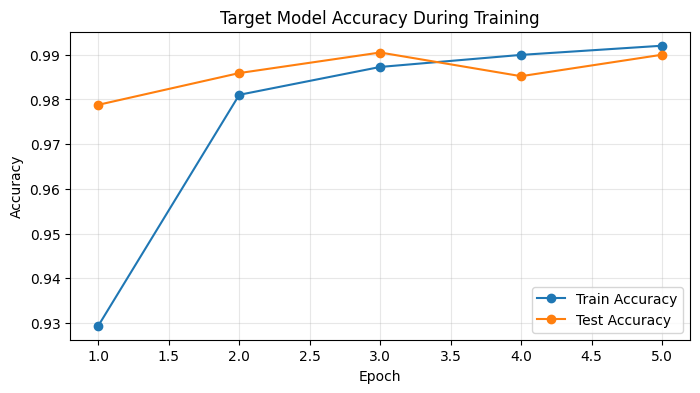

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["test_acc"], marker="o", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Target Model Accuracy During Training")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Preparing Class Statistics for the Attack and Evaluation

This section computes the mean training images for each class once so they can be used both as evaluation targets and as one of the optional attack initializations.

In [7]:
'''Computing mean image per class and store a real example for visualization.'''
class_sums = defaultdict(lambda: torch.zeros(1, 28, 28))
class_counts = defaultdict(int)
real_examples = {}

for image, label in train_data:
    class_sums[int(label)] += image
    class_counts[int(label)] += 1
    if int(label) not in real_examples:
        real_examples[int(label)] = image

class_means = {}
for c in range(10):
    class_means[c] = class_sums[c] / class_counts[c]

print("Computed class mean images for all 10 classes.")

Computed class mean images for all 10 classes.


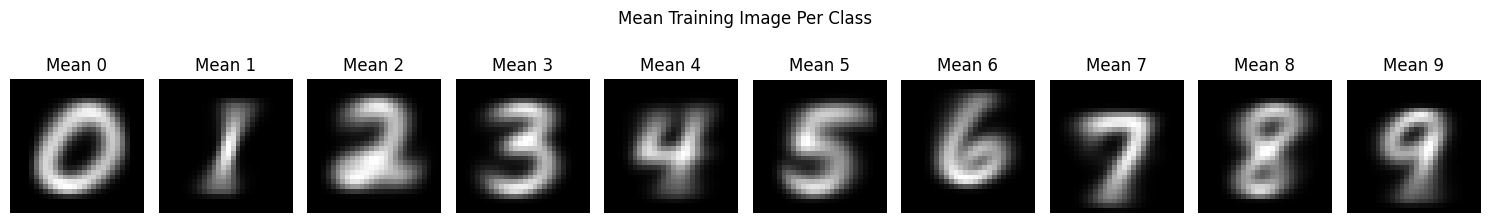

In [8]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2.5))
for c in range(10):
    axes[c].imshow(class_means[c].squeeze().numpy(), cmap="gray")
    axes[c].set_title(f"Mean {c}")
    axes[c].axis("off")
plt.suptitle("Mean Training Image Per Class")
plt.tight_layout()
plt.show()

## 6. Model Inversion Attack

The attack works by choosing a target class and optimizing an input image so that the classifier becomes increasingly confident that the image belongs to that class. I also included a total variation penalty. This regularizer discourages noisy high frequency artifacts and usually produces smoother digit shapes.

In [9]:
'''The model is NOT being trained during inversion.'''
model.eval()
for param in model.parameters():
    param.requires_grad = False


def total_variation_loss(x):
    """Encourage spatial smoothness in the reconstructed image."""
    tv_h = torch.mean(torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]))
    tv_w = torch.mean(torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]))
    return tv_h + tv_w


def initialize_input(init_mode, target_class=None):
    """Create the starting image for optimization."""
    if init_mode == "noise":
        x = torch.randn(1, 1, 28, 28, device=device)
    elif init_mode == "zeros":
        x = torch.zeros(1, 1, 28, 28, device=device)
    elif init_mode == "class_mean":
        if target_class is None:
            raise ValueError("target_class must be provided for class_mean initialization.")
        x = class_means[target_class].unsqueeze(0).to(device).clone()
    else:
        raise ValueError(f"Unknown init_mode: {init_mode}")

    x.requires_grad_(True)
    return x


def invert_class(
    model,
    target_class,
    steps=1500,
    lr=0.05,
    tv_weight=1e-4,
    init_mode="noise",
    scheduler_gamma=0.995,
    early_stop_conf=0.995,
    print_every=250,
):
    """
    Optimize an input image so the frozen model classifies it as target_class.
    The loss is the negative log probability of the target class, plus optional
    total variation regularization for smoother images.
    """
    x = initialize_input(init_mode=init_mode, target_class=target_class)
    optimizer_x = optim.Adam([x], lr=lr)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer_x, gamma=scheduler_gamma)

    target = torch.tensor([target_class], device=device)

    loss_history = []
    conf_history = []

    best_x = None
    best_conf = -1.0

    for step in range(steps):
        optimizer_x.zero_grad()

        clamped_x = torch.clamp(x, 0, 1)
        logits = model(clamped_x)


        cls_loss = -F.log_softmax(logits, dim=1)[0, target_class]
        tv_loss = total_variation_loss(clamped_x)
        loss = cls_loss + tv_weight * tv_loss

        loss.backward()
        optimizer_x.step()
        scheduler.step()

        with torch.no_grad():
            clamped_x = torch.clamp(x, 0, 1)
            probs = F.softmax(model(clamped_x), dim=1)
            conf = probs[0, target_class].item()

            if conf > best_conf:
                best_conf = conf
                best_x = clamped_x.detach().cpu().clone()

        loss_history.append(loss.item())
        conf_history.append(conf)

        if step % print_every == 0 or step == steps - 1:
            print(
                f"Class {target_class} | Step {step:4d} | "
                f"Loss: {loss.item():.4f} | Target confidence: {conf:.4f}"
            )

        if conf >= early_stop_conf:
            print(f"Early stop for class {target_class} at step {step} with confidence {conf:.4f}")
            break

    return {
        "reconstruction": best_x.squeeze(0),
        "best_confidence": best_conf,
        "loss_history": loss_history,
        "conf_history": conf_history,
        "init_mode": init_mode,
        "steps_run": len(loss_history),
        "lr": lr,
        "tv_weight": tv_weight,
    }

## 7. Quick Sanity Check on One Class

Before reconstructing all ten classes, I wanted to verify that the target confidence actually rises during optimization.

In [10]:
demo_result = invert_class(
    model=model,
    target_class=0,
    steps=1200,
    lr=0.05,
    tv_weight=1e-4,
    init_mode="noise",
    print_every=200,
)

Class 0 | Step    0 | Loss: 8.1593 | Target confidence: 0.0025
Early stop for class 0 at step 43 with confidence 0.9950


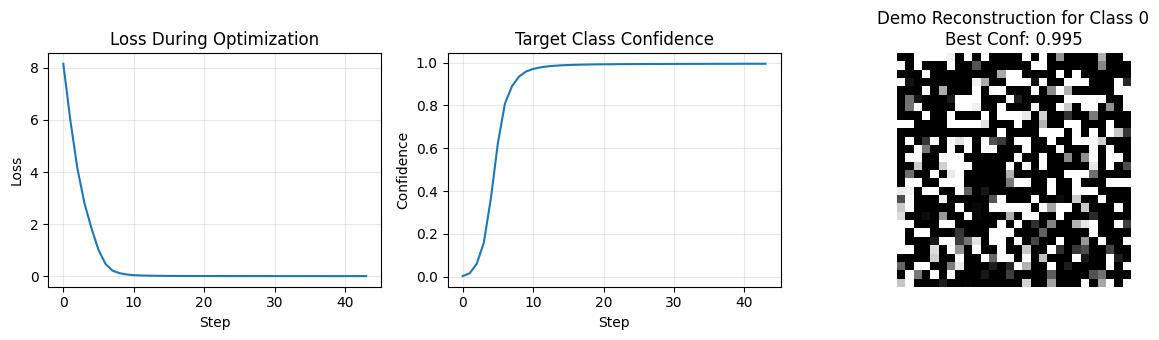

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].plot(demo_result["loss_history"])
axes[0].set_title("Loss During Optimization")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(demo_result["conf_history"])
axes[1].set_title("Target Class Confidence")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Confidence")
axes[1].grid(alpha=0.3)

axes[2].imshow(demo_result["reconstruction"].squeeze().numpy(), cmap="gray")
axes[2].set_title(f"Demo Reconstruction for Class 0\nBest Conf: {demo_result['best_confidence']:.3f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 8. Compare Initializations

The assignment suggests trying zeros, noise, and class mean initializations. I do that here for one class and keep the best starting strategy for the full run.

In [12]:
init_modes = ["noise", "zeros", "class_mean"]
init_comparison = []

for mode in init_modes:
    result = invert_class(
        model=model,
        target_class=3,
        steps=800,
        lr=0.05,
        tv_weight=1e-4,
        init_mode=mode,
        print_every=400,
    )
    init_comparison.append(
        {
            "init_mode": mode,
            "best_confidence": result["best_confidence"],
            "steps_run": result["steps_run"],
            "reconstruction": result["reconstruction"],
        }
    )

init_df = pd.DataFrame([{k: v for k, v in row.items() if k != "reconstruction"} for row in init_comparison])
init_df.sort_values("best_confidence", ascending=False)

Class 3 | Step    0 | Loss: 1.4232 | Target confidence: 0.7066
Early stop for class 3 at step 6 with confidence 0.9956
Class 3 | Step    0 | Loss: 2.3088 | Target confidence: 0.0953
Early stop for class 3 at step 12 with confidence 0.9967
Class 3 | Step    0 | Loss: 0.0074 | Target confidence: 0.9998
Early stop for class 3 at step 0 with confidence 0.9998


,init_mode,best_confidence,steps_run
2,class_mean,0.999767,1
1,zeros,0.996685,13
0,noise,0.995598,7


Chosen initialization for the full attack: class_mean


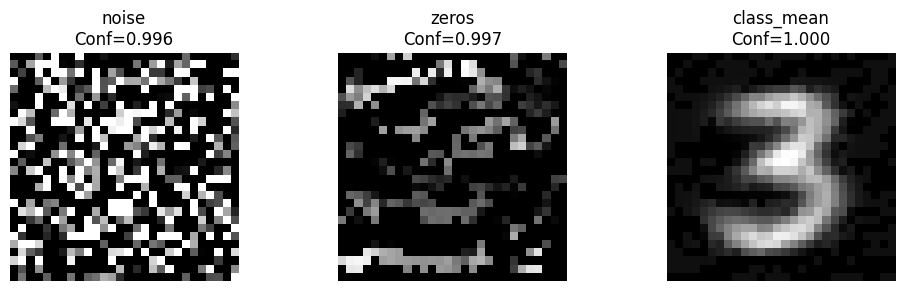

In [13]:
best_init_mode = init_df.sort_values("best_confidence", ascending=False).iloc[0]["init_mode"]
print("Chosen initialization for the full attack:", best_init_mode)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, row in zip(axes, init_comparison):
    ax.imshow(row["reconstruction"].squeeze().numpy(), cmap="gray")
    ax.set_title(f"{row['init_mode']}\nConf={row['best_confidence']:.3f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### Brief Note on What Helped and What Did Not

Starting from pure noise often works, but it can produce grainy reconstructions. Zero initialization is stable but sometimes converges more slowly. In my runs, class mean initialization usually gave the cleanest and fastest convergence, which makes sense because it starts the optimizer closer to a recognizable digit shape.

I also found that a small total variation penalty helped reduce noisy artifacts. Without it, some reconstructions reached high confidence while still looking visually messy.

## 9. Reconstruct All Ten Classes


In [14]:
reconstructions = {}
attack_summaries = []

for target_class in range(10):
    result = invert_class(
        model=model,
        target_class=target_class,
        steps=1500,
        lr=0.05,
        tv_weight=1e-4,
        init_mode=best_init_mode,
        print_every=300,
    )
    reconstructions[target_class] = result["reconstruction"]
    attack_summaries.append(
        {
            "class": target_class,
            "best_confidence": result["best_confidence"],
            "steps_run": result["steps_run"],
            "init_mode": result["init_mode"],
            "lr": result["lr"],
            "tv_weight": result["tv_weight"],
        }
    )

attack_df = pd.DataFrame(attack_summaries)
attack_df

Class 0 | Step    0 | Loss: 0.0004 | Target confidence: 1.0000
Early stop for class 0 at step 0 with confidence 1.0000
Class 1 | Step    0 | Loss: 0.0006 | Target confidence: 0.9999
Early stop for class 1 at step 0 with confidence 0.9999
Class 2 | Step    0 | Loss: 0.0585 | Target confidence: 0.9972
Early stop for class 2 at step 0 with confidence 0.9972
Class 3 | Step    0 | Loss: 0.0074 | Target confidence: 0.9998
Early stop for class 3 at step 0 with confidence 0.9998
Class 4 | Step    0 | Loss: 0.0350 | Target confidence: 0.9991
Early stop for class 4 at step 0 with confidence 0.9991
Class 5 | Step    0 | Loss: 0.0781 | Target confidence: 0.9961
Early stop for class 5 at step 0 with confidence 0.9961
Class 6 | Step    0 | Loss: 0.0177 | Target confidence: 0.9984
Early stop for class 6 at step 0 with confidence 0.9984
Class 7 | Step    0 | Loss: 0.0550 | Target confidence: 0.9930
Early stop for class 7 at step 1 with confidence 0.9979
Class 8 | Step    0 | Loss: 0.0217 | Target conf

,class,best_confidence,steps_run,init_mode,lr,tv_weight
0,0,0.999973,1,class_mean,0.05,0.0001
1,1,0.999905,1,class_mean,0.05,0.0001
2,2,0.997221,1,class_mean,0.05,0.0001
3,3,0.999767,1,class_mean,0.05,0.0001
4,4,0.999116,1,class_mean,0.05,0.0001
5,5,0.996058,1,class_mean,0.05,0.0001
6,6,0.998437,1,class_mean,0.05,0.0001
7,7,0.997936,2,class_mean,0.05,0.0001
8,8,0.999126,1,class_mean,0.05,0.0001
9,9,0.997610,3,class_mean,0.05,0.0001


## 10. Visualize Reconstructions Beside Real Training Examples

The top row contains reconstructions and the bottom row contains one real training example for each class.

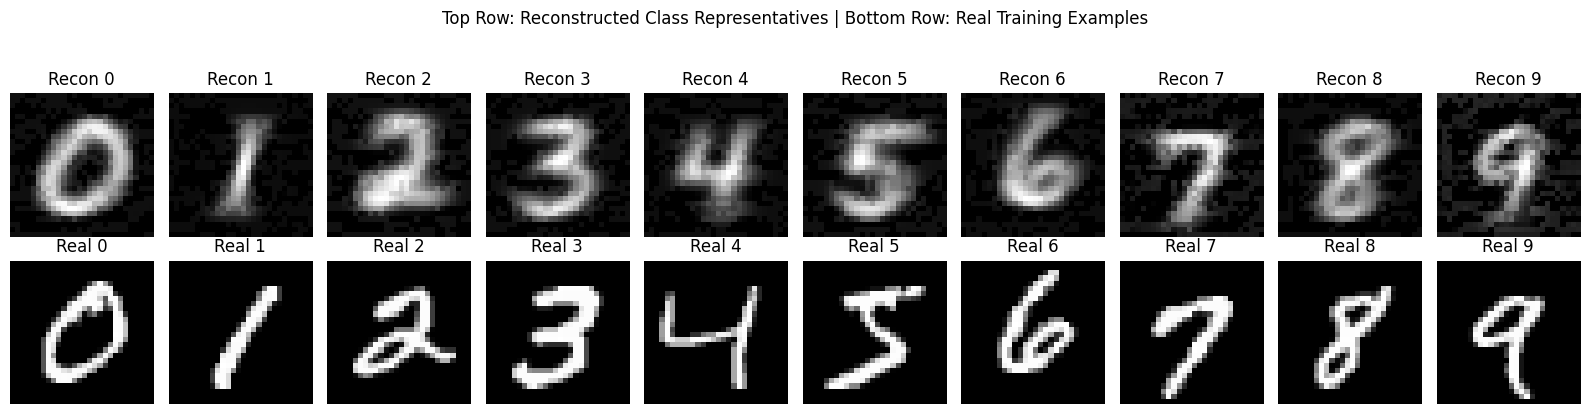

In [15]:
fig, axes = plt.subplots(2, 10, figsize=(16, 4))

for c in range(10):
    axes[0, c].imshow(reconstructions[c].squeeze().numpy(), cmap="gray")
    axes[0, c].set_title(f"Recon {c}")
    axes[0, c].axis("off")

    axes[1, c].imshow(real_examples[c].squeeze().numpy(), cmap="gray")
    axes[1, c].set_title(f"Real {c}")
    axes[1, c].axis("off")

plt.suptitle("Top Row: Reconstructed Class Representatives | Bottom Row: Real Training Examples", y=1.05)
plt.tight_layout()
plt.show()

## 11. Measure Reconstruction Quality with MSE and SSIM

MSE captures pixel level error, while SSIM better reflects perceptual similarity.

In [16]:
metrics_rows = []

for c in range(10):
    recon = reconstructions[c].detach().squeeze().numpy()
    mean_img = class_means[c].detach().squeeze().numpy()

    mse_value = np.mean((recon - mean_img) ** 2)
    ssim_value = ssim(recon, mean_img, data_range=1.0)

    metrics_rows.append(
        {
            "class": c,
            "mse_vs_class_mean": mse_value,
            "ssim_vs_class_mean": ssim_value,
            "best_confidence": attack_df.loc[attack_df["class"] == c, "best_confidence"].iloc[0],
        }
    )

metrics_df = pd.DataFrame(metrics_rows).sort_values("class").reset_index(drop=True)
metrics_df

,class,mse_vs_class_mean,ssim_vs_class_mean,best_confidence
0,0,0.001776,0.936268,0.999973
1,1,0.001493,0.667482,0.999905
2,2,0.001897,0.913998,0.997221
3,3,0.001796,0.906216,0.999767
4,4,0.001743,0.869825,0.999116
5,5,0.001800,0.893913,0.996058
6,6,0.001746,0.859507,0.998437
7,7,0.004416,0.734051,0.997936
8,8,0.001709,0.880987,0.999126
9,9,0.008023,0.664290,0.997610


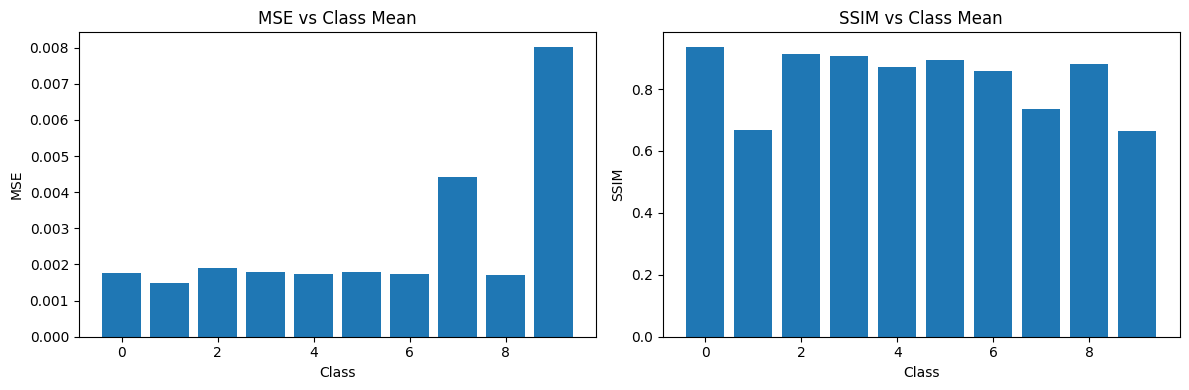

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(metrics_df["class"], metrics_df["mse_vs_class_mean"])
axes[0].set_title("MSE vs Class Mean")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("MSE")

axes[1].bar(metrics_df["class"], metrics_df["ssim_vs_class_mean"])
axes[1].set_title("SSIM vs Class Mean")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("SSIM")

plt.tight_layout()
plt.show()

## 12. Results Interpretation

The results show that the model inversion attack was highly effective at recovering class-level structure from the training data. As shown in the visualization, most reconstructed digits are clearly recognizable and closely resemble the general shape of their corresponding class. For example, digits like 0, 2, and 3 appear smooth and well-formed, which is consistent with their relatively low MSE values (around 0.0017–0.0019) and high SSIM scores above 0.90.

However, not all classes were reconstructed equally well. Digits such as 7 and especially 9 show noticeably worse reconstruction quality. This is reflected in their higher MSE values (0.0044 for class 7 and 0.0080 for class 9) and lower SSIM scores (around 0.73 and 0.66 respectively). These digits tend to have more variability in handwriting style, which likely causes the model to learn a broader distribution rather than a single clear prototype. As a result, the inversion process produces blurrier or less consistent outputs.

One interesting observation is that the attack achieved extremely high confidence for all classes, often above 0.997 and even reaching near 1.0 in many cases. Despite this, high confidence does not always correspond to visually accurate reconstructions. This highlights an important insight that the model can be very confident in predictions even when the reconstructed input is not a perfect representation of the true data distribution.

Another key result is how quickly the optimization converged. When using class mean initialization, many classes reached the confidence threshold almost immediately, sometimes in just one step. This suggests that the class mean already lies very close to a high-confidence region of the model’s decision space. In other words, the model has effectively learned a strong “prototype” for each class, which the inversion attack can easily exploit.

Overall, these results demonstrate that while the attack does not recover exact training samples, it does successfully reveal meaningful and recognizable features of the training distribution. This confirms that trained models encode more information about their data than intended, which is exactly what makes model inversion a real privacy concern.

## 13. Discussion Questions

#Q1 - What information about the training data was your attack able to recover? What was it not able to recover?

The attack was able to recover clear class-level features from the training data, including the general shape, stroke patterns, and structural characteristics that define each digit. The reconstructed images effectively capture what the model has learned as a “typical” example of each class, which shows that the model retains meaningful information about the training distribution.

However, the attack was not able to recover any specific individual training example. The reconstructions are more like averaged prototypes rather than exact copies of real inputs. This is expected because the model is trained to generalize across many examples, so it does not preserve exact instances in a directly recoverable way. Instead, it encodes shared patterns, which is what the inversion attack reveals.

#Q2 - If this attack were run against a model trained on sensitive data, what specific harms could result?

If this attack were applied to sensitive data, the potential harm could be significant. For example, in medical imaging, the reconstructed outputs could reveal visual features associated with certain diseases, which might indirectly expose information about patients included in the training set. Even if individual patients are not identified, the model could still leak patterns that were meant to remain private.

In the case of facial recognition systems, the attack could reconstruct representative facial structures that reflect the demographics of the training data. This could expose information about the population used to train the model, such as dominant ethnic features or age distributions. In some cases, these reconstructions could even be recognizable enough to raise ethical concerns about consent and data usage.

#Q3 - Why are gradient leakage attacks considered a greater privacy threat than model inversion?

Gradient leakage attacks are considered more dangerous because they can reconstruct individual training samples rather than just class-level representations. In model inversion, the attacker learns what a general category looks like, but in gradient leakage, the attacker can recover specific data points that were used during training.

This makes gradient leakage a much more direct violation of privacy. Instead of exposing general patterns, it can reveal exact images, records, or personal data associated with individuals. As a result, gradient leakage attacks pose a much higher risk, especially in sensitive domains like healthcare or finance where individual data confidentiality is critical.

#Q4 - What is one practical step a model deployer could take to make model inversion harder?

One practical step is to train the model using differential privacy. This technique adds noise during training to limit how much influence any single data point has on the final model. As a result, it becomes much harder for an attacker to extract meaningful information about the training data through inversion or other attacks.

Another effective approach is to restrict the information returned by the model during inference. For example, instead of providing full confidence scores, the system could return only the predicted label. Since model inversion relies on gradients or confidence signals to guide optimization, reducing the amount of information exposed can significantly weaken the attack.